<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#1---File-formats---JPG,-PNG,-PDF-&amp;-Extent" data-toc-modified-id="1---File-formats---JPG,-PNG,-PDF-&amp;-Extent-1">1 - File formats - JPG, PNG, PDF &amp; Extent</a></span><ul class="toc-item"><li><span><a href="#JPG" data-toc-modified-id="JPG-1.1">JPG</a></span></li><li><span><a href="#PNG32" data-toc-modified-id="PNG32-1.2">PNG32</a></span></li><li><span><a href="#PDF" data-toc-modified-id="PDF-1.3">PDF</a></span></li></ul></li><li><span><a href="#2-Change-DPI" data-toc-modified-id="2-Change-DPI-2">2 Change DPI</a></span></li><li><span><a href="#3-Change-map-image-dimensions" data-toc-modified-id="3-Change-map-image-dimensions-3">3 Change map image dimensions</a></span></li><li><span><a href="#4.-Change-map-scale" data-toc-modified-id="4.-Change-map-scale-4">4. Change map scale</a></span></li><li><span><a href="#5.-Rotation" data-toc-modified-id="5.-Rotation-5">5. Rotation</a></span></li><li><span><a href="#6.-Layouts---A4,-Letter" data-toc-modified-id="6.-Layouts---A4,-Letter-6">6. Layouts - A4, Letter</a></span></li><li><span><a href="#7.-Complex-map" data-toc-modified-id="7.-Complex-map-7">7. Complex map</a></span></li><li><span><a href="#Download-image-file" data-toc-modified-id="Download-image-file-8">Download image file</a></span></li></ul></div>

# Test WebMap.print() function

In [1]:
# When using `geosaurus_dev_env` conda env

# import sys
# sys.path.append('/Users/atma6951/Documents/code/geosurus/geosaurus/src')

In [2]:
from arcgis.gis import GIS
from arcgis.mapping import WebMap, export_map, get_layout_templates
from arcgis.geometry import Point
from arcgis.features import FeatureSet, FeatureCollection, Feature
from arcgis.geocoding import geocode

import json
import requests
from IPython.display import Image
import matplotlib.pyplot as plt

import time

In [3]:
gis = GIS()

In [4]:
pt1 = Point([-117.18, 34.05])
ft = Feature(pt1, attributes={'name':'Redlands'})
fset = FeatureSet([ft])
fc = FeatureCollection.from_featureset(fset)
fc

<FeatureCollection>

In [5]:
redlands_extent = {'spatialReference': {'latestWkid': 3857, 'wkid': 102100},
 'xmin': -13074746.000753032,
 'ymin': 4020957.451106308,
 'xmax': -13014666.49652086,
 'ymax': 4051532.26242039}

ca_extent = {'spatialReference': {'latestWkid': 3857, 'wkid': 102100},
 'xmin': -15199645.40582486,
 'ymin': 3395607.5273594954,
 'xmax': -11354557.134968376,
 'ymax': 5352395.451459487}

In [6]:
map2 = gis.map('California')
map2

MapView(layout=Layout(height='400px', width='100%'))

In [7]:
map2.extent

{'xmin': -124.20822999999997,
 'ymin': 31.436105693000048,
 'xmax': -114.33222999999997,
 'ymax': 41.31210569300005}

In [8]:
map2.scale

-1.0

In [9]:
map2.rotation

0.0

## 1 - File formats - JPG, PNG, PDF & Extent

In [10]:
wm1 = WebMap()
wm1.basemap = 'streets-vector'

In [11]:
wm1.add_layer(fc)

True

### JPG

In [12]:
%%time
print_jpg = wm1.print(file_format='JPG', extent=redlands_extent)
print_jpg

CPU times: user 21.5 ms, sys: 4.33 ms, total: 25.8 ms
Wall time: 1min 2s


'https://utility.arcgisonline.com/arcgis/rest/directories/arcgisoutput/Utilities/PrintingTools_GPServer/x_____xmOuB-WrkZPNPjoUSvmv2yw..x_____x_ags_c71f2f30-7c79-11eb-b8e8-22000ae11289.jpg'

### PNG32

In [13]:
time.sleep(30)

In [14]:
%%time
print_png = wm1.print(file_format='PNG32', extent=redlands_extent)

CPU times: user 22.9 ms, sys: 3.86 ms, total: 26.8 ms
Wall time: 12.5 s


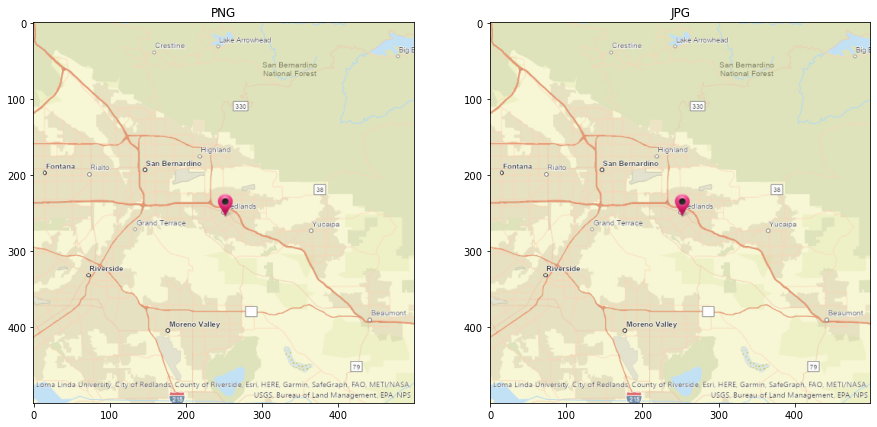

In [15]:
fig, ax = plt.subplots(1,2, figsize=(15,10))
ppng = plt.imread(print_png)
ax[0].imshow(ppng)
ax[0].set_title('PNG');

pjpg = plt.imread(print_jpg, format='JPG')
ax[1].imshow(pjpg)
ax[1].set_title('JPG');

### PDF

In [16]:
time.sleep(30)

In [17]:
%%time
print_pdf = wm1.print(file_format='PDF', extent=ca_extent)

CPU times: user 8.79 ms, sys: 2.75 ms, total: 11.5 ms
Wall time: 36.3 s


In [18]:
print_pdf

'https://utility.arcgisonline.com/arcgis/rest/directories/arcgisoutput/Utilities/PrintingTools_GPServer/x_____xOSAnK3_IT9yT2szKzgO7iA..x_____x_ags_0db7375e-7c7a-11eb-a6d7-22000b8e8a59.pdf'

## 2 Change DPI

In [19]:
time.sleep(30)

In [20]:
%%time
print_150dpi = wm1.print(file_format='JPG', extent=ca_extent, dpi=150)
print_300dpi = wm1.print(file_format='JPG', extent=ca_extent, dpi=300)

CPU times: user 26 ms, sys: 4.31 ms, total: 30.3 ms
Wall time: 6.79 s


Text(0.5, 1.0, '300 DPI')

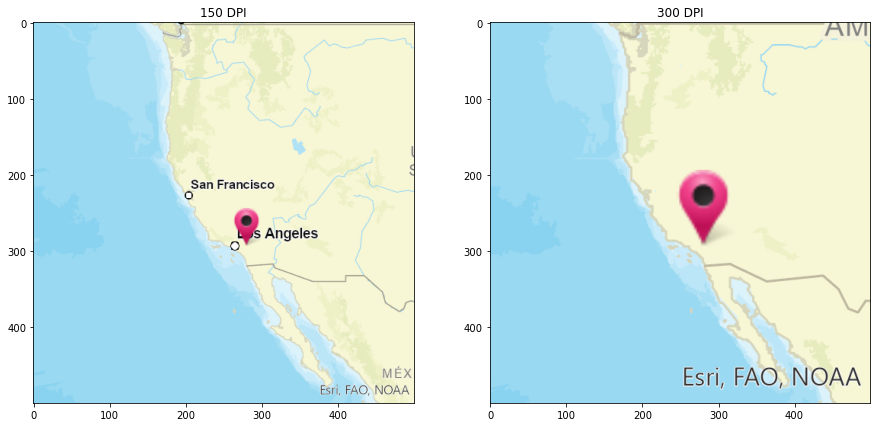

In [21]:
fig, ax = plt.subplots(1,2, figsize=(15,10))
p1 = plt.imread(print_150dpi, format='JPG')
ax[0].imshow(p1)
ax[0].set_title('150 DPI');

p1 = plt.imread(print_300dpi, format='JPG')
ax[1].imshow(p1)
ax[1].set_title('300 DPI')

## 3 Change map image dimensions

In [22]:
time.sleep(30)

In [23]:
%%time
print_300x300 = wm1.print(file_format='JPG', 
                          extent=ca_extent, output_dimensions=[300,300])
print_600x400 = wm1.print(file_format='JPG', 
                          extent=ca_extent, output_dimensions=[600,400])

CPU times: user 14.6 ms, sys: 2.82 ms, total: 17.4 ms
Wall time: 12.8 s


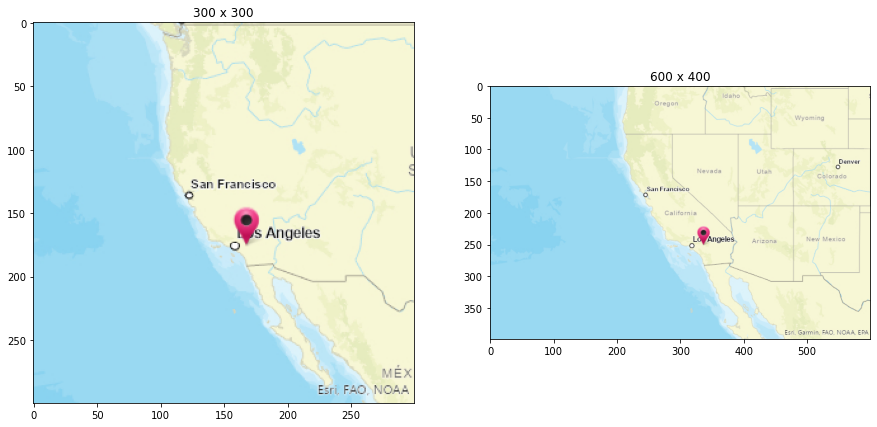

In [24]:
fig, ax = plt.subplots(1,2, figsize=(15,10))
p1 = plt.imread(print_300x300, format='JPG')
ax[0].imshow(p1)
ax[0].set_title('300 x 300');

p1 = plt.imread(print_600x400, format='JPG')
ax[1].imshow(p1)
ax[1].set_title('600 x 400');

## 4. Change map scale

In [25]:
time.sleep(30)

In [26]:
%%time
print_36k = wm1.print(file_format='JPG', 
                          extent=redlands_extent, scale=36000)

print_150k = wm1.print(file_format='JPG', 
                          extent=redlands_extent, scale=150000)

CPU times: user 15.1 ms, sys: 3.21 ms, total: 18.3 ms
Wall time: 18.5 s


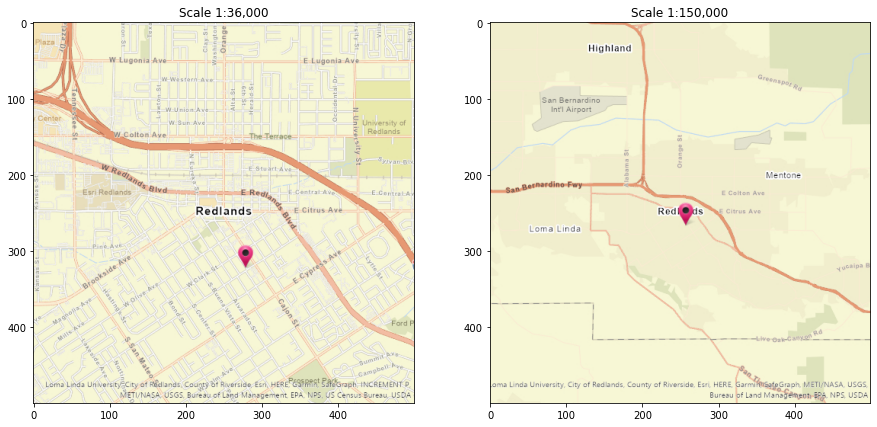

In [27]:
fig, ax = plt.subplots(1,2, figsize=(15,10))
p1 = plt.imread(print_36k, format='JPG')
ax[0].imshow(p1)
ax[0].set_title('Scale 1:36,000');

p1 = plt.imread(print_150k, format='JPG')
ax[1].imshow(p1)
ax[1].set_title('Scale 1:150,000');

## 5. Rotation

In [28]:
# %%time
# print_90e = wm1.print(file_format='JPG', 
#                           extent=redlands_extent, rotation=90)

# print_180s = wm1.print(file_format='JPG', 
#                           extent=redlands_extent, rotation=180)

In [29]:
# fig, ax = plt.subplots(1,2, figsize=(15,10))
# p1 = plt.imread(print_90e, format='JPG')
# ax[0].imshow(p1)
# ax[0].set_title('Rotation: 90 deg');

# p1 = plt.imread(print_180s, format='JPG')
# ax[1].imshow(p1)
# ax[1].set_title('Rotation: 180 deg');

## 6. Layouts - A4, Letter

In [30]:
time.sleep(30)

In [31]:
[i['layoutTemplate'] for i  in get_layout_templates()]

['A3 Landscape',
 'A3 Portrait',
 'A4 Landscape',
 'A4 Portrait',
 'Letter ANSI A Landscape',
 'Letter ANSI A Portrait',
 'Tabloid ANSI B Landscape',
 'Tabloid ANSI B Portrait']

In [32]:
time.sleep(30)

In [33]:
%%time
print_a4land = wm1.print(file_format='JPG', 
                          extent=redlands_extent, layout_template='A4 Landscape')

print_let_port = wm1.print(file_format='JPG', 
                          extent=redlands_extent, layout_template='Letter ANSI A Portrait')

CPU times: user 14.1 ms, sys: 3.57 ms, total: 17.7 ms
Wall time: 14.9 s


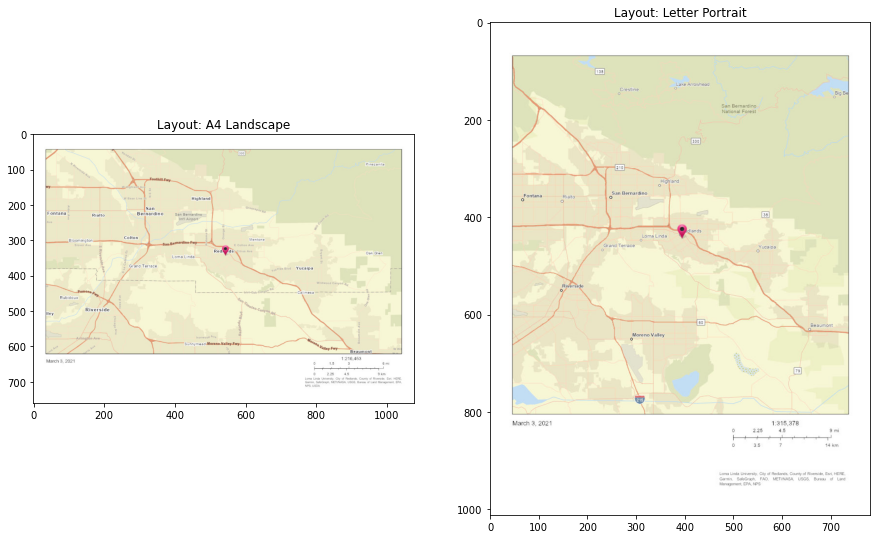

In [34]:
fig, ax = plt.subplots(1,2, figsize=(15,10))
p1 = plt.imread(print_a4land, format='JPG')
ax[0].imshow(p1)
ax[0].set_title('Layout: A4 Landscape');

p1 = plt.imread(print_let_port, format='JPG')
ax[1].imshow(p1)
ax[1].set_title('Layout: Letter Portrait');

## 7. Complex map

In [35]:
time.sleep(30)

In [36]:
wm_item = gis.content.get('c6ba9c02006948b9bdc1d66436fa5d29')
complex_wm = WebMap(wm_item)

In [37]:
%%time
print_a4land_c = complex_wm.print(file_format='JPG', 
                          extent=ca_extent, layout_template='A4 Landscape')

CPU times: user 12.4 ms, sys: 3.32 ms, total: 15.7 ms
Wall time: 43.4 s


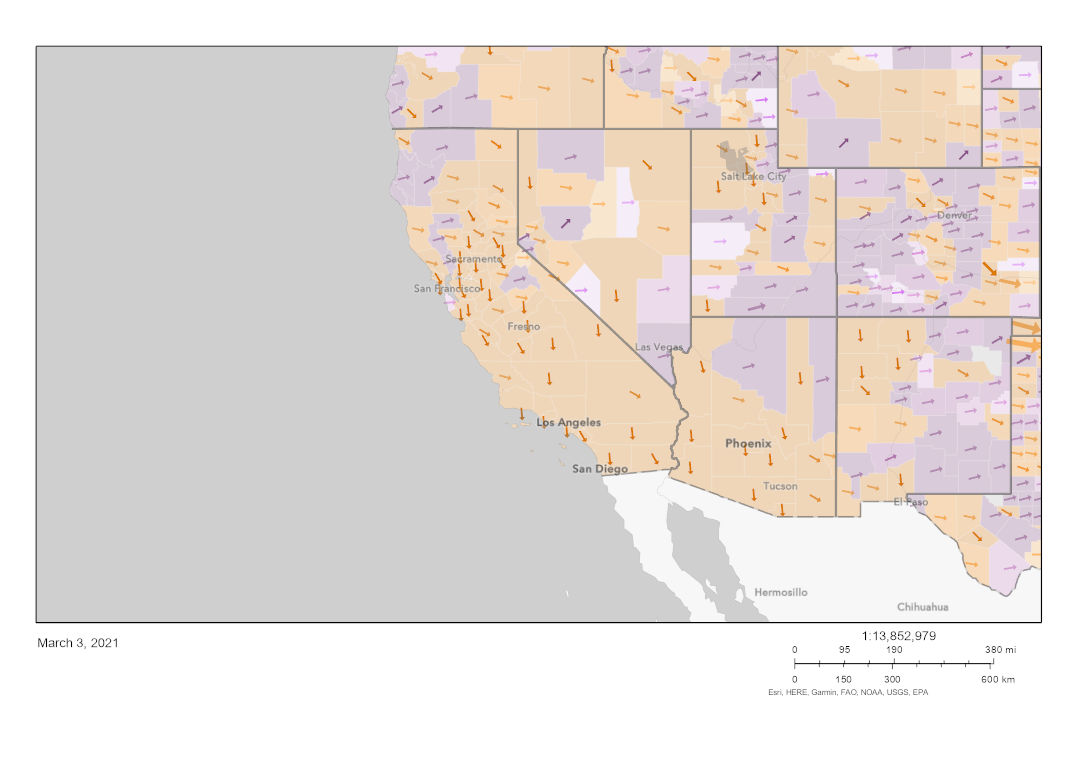

In [38]:
Image(print_a4land_c)

## Download image file

In [39]:
import requests

In [40]:
with requests.get(print_png) as resp:
    with open('./output_file.png', 'wb') as file_handle:
        file_handle.write(resp.content)